In [ ]:
import pandas as pd# For data manipulation (DataFrames)
import glob# For finding files matching a pattern
import os# For operating system path utilities
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Find all CSV files in the folder
all_files = glob.glob(folder + '*.csv')
print(f"Found {len(all_files)} CSV files:")
for f in sorted(all_files):
    print(f"{os.path.basename(f)}")
# Read and combine all files into one DataFrame
df = pd.concat(
    [pd.read_csv(f) for f in all_files],
    ignore_index=True
    # Resets row index to 0, 1, 2, ...
)
print(f"\nAll files loaded! Shape: {df.shape}")

Found 12 CSV files:
PRSA_Data_Aotizhongxin_20130301-20170228.csv
PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Nongzhanguan_20130301-20170228.csv
PRSA_Data_Shunyi_20130301-20170228.csv
PRSA_Data_Tiantan_20130301-20170228.csv
PRSA_Data_Wanliu_20130301-20170228.csv
PRSA_Data_Wanshouxigong_20130301-20170228.csv

All files loaded! Shape: (420768, 18)


In [ ]:
print("=== FIRST 5 ROWS OF THE COMBINED DATASET ===")
df.head()
# Shows top 5 rows as a formatted table in Colab

=== FIRST 5 ROWS OF THE COMBINED DATASET ===


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [ ]:
print("=== COLUMN NAMES ===")
print(df.columns.tolist())
print(f"\nTotal number of columns: {len(df.columns)}")

=== COLUMN NAMES ===
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Total number of columns: 18


In [ ]:
print("=== COLUMN DATA TYPES ===")
print(df.dtypes)

=== COLUMN DATA TYPES ===
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object


In [ ]:
rows, cols = df.shape
print("=== DATASET DIMENSIONS ===")
print(f"Total Rows: {rows:,}")
print(f"Total Columns : {cols}")

=== DATASET DIMENSIONS ===
Total Rows: 420,768
Total Columns : 18


In [ ]:
print("=== FULL DATASET INFO ===")
df.info()

=== FULL DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [ ]:
print("=== MISSING VALUES PER COLUMN ===")
missing = df.isnull().sum()
print(missing[missing > 0])
# Only show columns WITH missing values

=== MISSING VALUES PER COLUMN ===
PM2.5     8739
PM10      6449
SO2       9021
NO2      12116
CO       20701
O3       13277
TEMP       398
PRES       393
DEWP       403
RAIN       390
wd        1822
WSPM       318
dtype: int64


In [ ]:
print("=== STATIONS IN DATASET ===")
print(df['station'].unique())
print(f"Number of stations: {df['station'].nunique()}")

=== STATIONS IN DATASET ===
['Changping' 'Gucheng' 'Dongsi' 'Wanshouxigong' 'Dingling' 'Tiantan'
 'Wanliu' 'Shunyi' 'Aotizhongxin' 'Huairou' 'Guanyuan' 'Nongzhanguan']
Number of stations: 12


### 1. Distribution of PM2.5

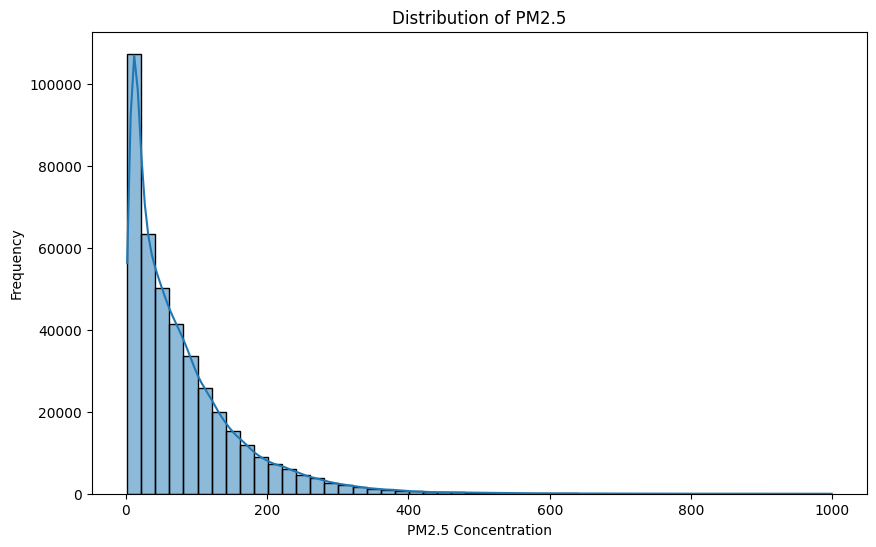

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['PM2.5'].dropna(), bins=50, kde=True)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Frequency')
plt.show()

### 2. Seasonal Trends of PM2.5

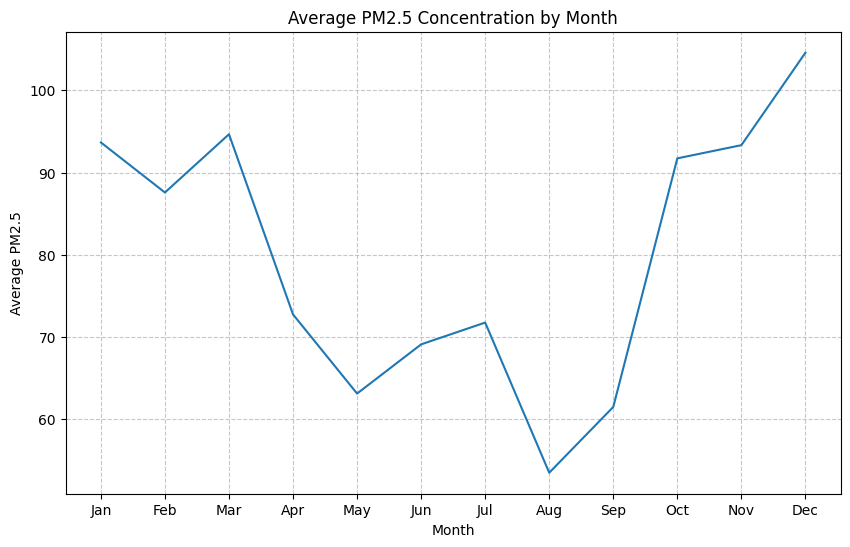

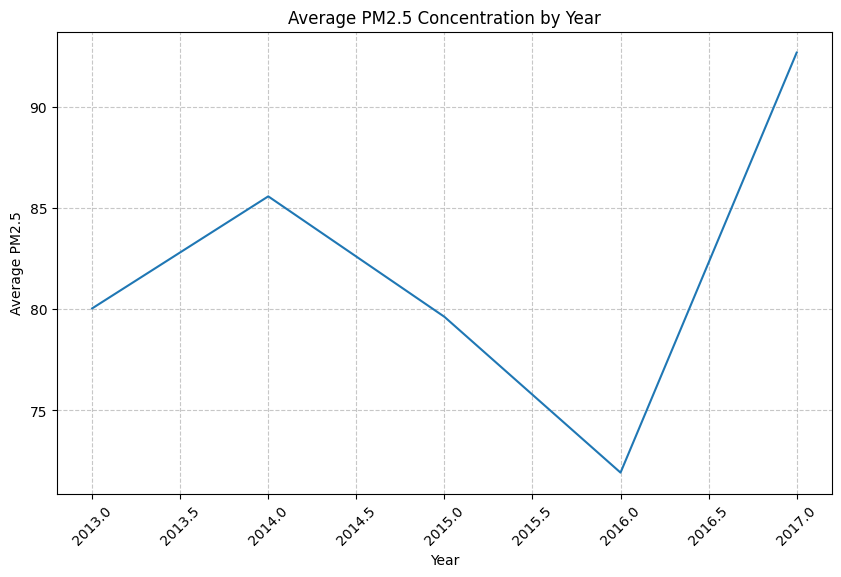

In [27]:
# Average PM2.5 by month
monthly_avg_pm25 = df.groupby('month')['PM2.5'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='PM2.5', data=monthly_avg_pm25)
plt.title('Average PM2.5 Concentration by Month')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Average PM2.5 by year
yearly_avg_pm25 = df.groupby('year')['PM2.5'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='PM2.5', data=yearly_avg_pm25)
plt.title('Average PM2.5 Concentration by Year')
plt.xlabel('Year')
plt.ylabel('Average PM2.5')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 3. Correlation Analysis

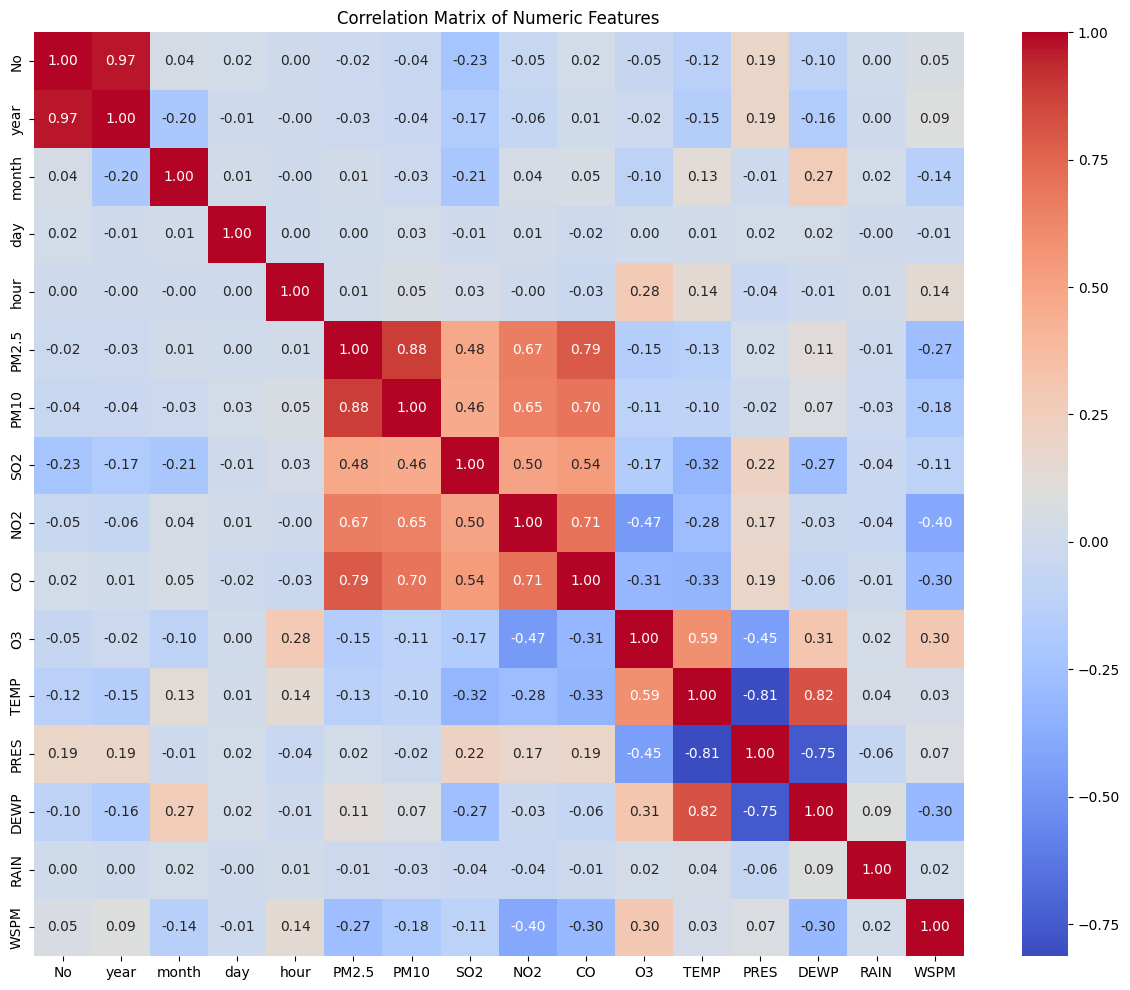

In [28]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### 4. Average Pollution Levels

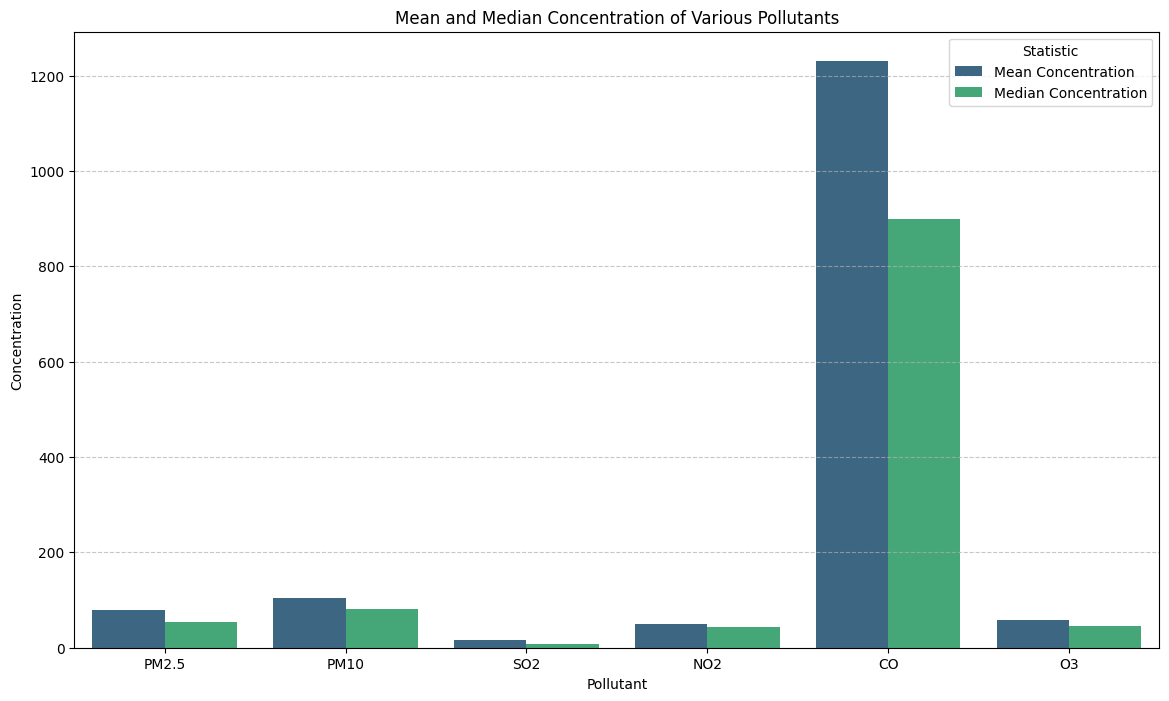

In [31]:
# Define the list of pollutants
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Calculate mean concentrations for key pollutants
mean_pollution_levels = df[pollutants].mean().reset_index()
mean_pollution_levels.columns = ['Pollutant', 'Mean Concentration']

# Calculate median concentrations for key pollutants
median_pollution_levels = df[pollutants].median().reset_index()
median_pollution_levels.columns = ['Pollutant', 'Median Concentration']

# Combine mean and median into a single DataFrame
summary_pollution_levels = pd.merge(mean_pollution_levels, median_pollution_levels, on='Pollutant')

# Melt the DataFrame to prepare for a grouped bar chart
summary_pollution_melted = summary_pollution_levels.melt(id_vars='Pollutant', var_name='Statistic', value_name='Concentration')

plt.figure(figsize=(14, 8))
sns.barplot(x='Pollutant', y='Concentration', hue='Statistic', data=summary_pollution_melted, palette='viridis')
plt.title('Mean and Median Concentration of Various Pollutants')
plt.xlabel('Pollutant')
plt.ylabel('Concentration')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Statistic')
plt.show()